1. Fit our VAE on the CIFAR-10 images, and observe the distribution of the
samples corresponding to each class in a 2D space. Change the latent dimension to 3D. Discuss the results. (To get the ability to zoom in/out, change perspective in pyplot 3D space, load the predictions locally, and use the GUI provided by matplotlib instead of the colab non-interactive windows). Use t-SNE to reproject into observable 2D or 3D representations. Does the distribution in the latent space make intuitive sense?

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_6 (Conv2D)              (None, 16, 16, 32)   896         ['input_7[0][0]']                
                                                                                                  
 conv2d_7 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d_6[0][0]']               
                                                                                                  
 flatten_3 (Flatten)            (None, 4096)         0           ['conv2d_7[0][0]']               
                                                                                            

Epoch 1/30
391/391 [==============================] - 118s 297ms/step - loss: 691.6312 - reconstruction_loss: 677.4617 - kl_loss: 3.1102
Epoch 2/30
391/391 [==============================] - 116s 298ms/step - loss: 666.9472 - reconstruction_loss: 659.3532 - kl_loss: 3.8711
Epoch 3/30
391/391 [==============================] - 115s 294ms/step - loss: 656.2646 - reconstruction_loss: 651.9925 - kl_loss: 4.1373
Epoch 4/30
391/391 [==============================] - 116s 296ms/step - loss: 655.4988 - reconstruction_loss: 651.5037 - kl_loss: 4.0685
Epoch 5/30
391/391 [==============================] - 114s 293ms/step - loss: 655.6698 - reconstruction_loss: 651.2770 - kl_loss: 4.0517
Epoch 6/30
391/391 [==============================] - 115s 295ms/step - loss: 655.4803 - reconstruction_loss: 651.2272 - kl_loss: 4.0674
Epoch 7/30
391/391 [==============================] - 114s 293ms/step - loss: 655.4540 - reconstruction_loss: 651.1085 - kl_loss: 4.0665
Epoch 8/30
391/391 [=====================

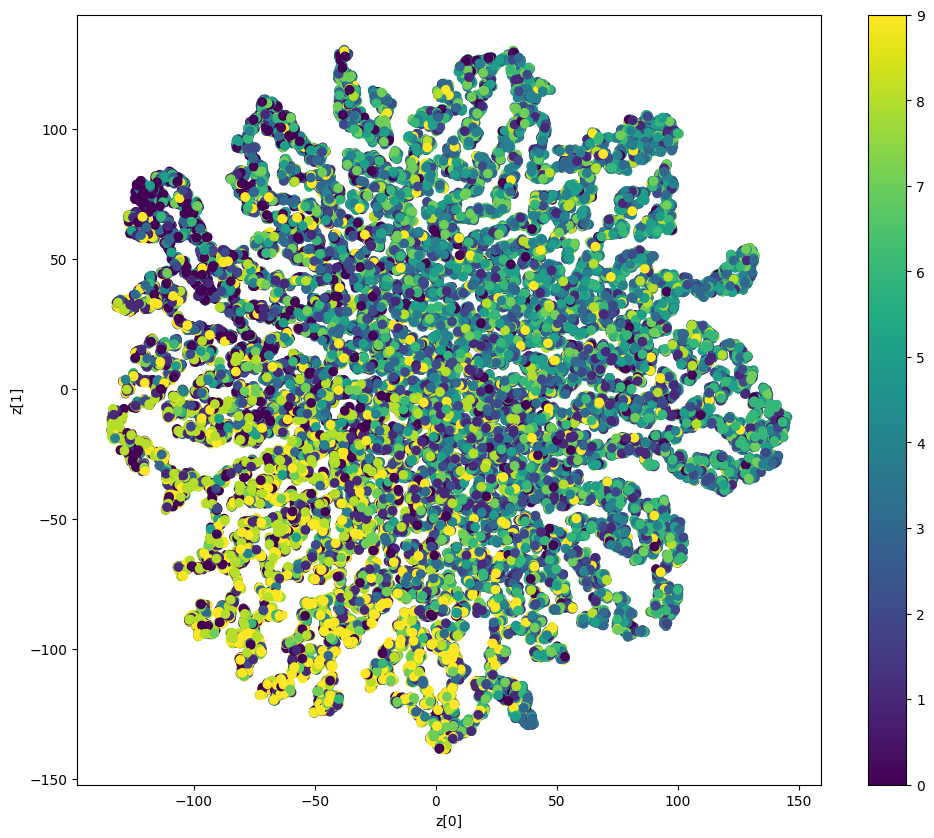

Epoch 1/50
391/391 [==============================] - 119s 305ms/step - loss: 654.0176 - reconstruction_loss: 649.3619 - kl_loss: 4.3232
Epoch 2/50
391/391 [==============================] - 121s 308ms/step - loss: 653.4469 - reconstruction_loss: 649.2158 - kl_loss: 4.3346
Epoch 3/50
391/391 [==============================] - 120s 308ms/step - loss: 653.4918 - reconstruction_loss: 649.2131 - kl_loss: 4.3570
Epoch 4/50
391/391 [==============================] - 121s 308ms/step - loss: 653.1885 - reconstruction_loss: 649.1124 - kl_loss: 4.3708
Epoch 5/50
391/391 [==============================] - 122s 312ms/step - loss: 653.1100 - reconstruction_loss: 649.0377 - kl_loss: 4.3784
Epoch 6/50
391/391 [==============================] - 120s 308ms/step - loss: 653.3270 - reconstruction_loss: 649.0136 - kl_loss: 4.3834
Epoch 7/50
391/391 [==============================] - 123s 315ms/step - loss: 653.4052 - reconstruction_loss: 648.9094 - kl_loss: 4.3919
Epoch 8/50
391/391 [=====================

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Layer, Conv2D, Conv2DTranspose, Dense, Flatten, Reshape
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

class SamplingLayer(Layer):
    def call(self, inputs):
        mean, log_variance = inputs
        bs = tf.shape(mean)[0]
        dim = tf.shape(mean)[1]
        eps = tf.random.normal(shape=(bs, dim))
        return mean + eps * tf.exp(0.5 * log_variance)

latent_dim = 2

# Encoder
encoder_input = keras.Input(shape=(32, 32, 3))
x = Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)
x = Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = Flatten()(x)
latent = Dense(128, activation="relu")(x)
mean = Dense(latent_dim, name="mean")(latent)
log_variance = Dense(latent_dim, name="log_variance")(latent)
latent_sample = SamplingLayer()((mean, log_variance))
encoder = keras.Model(encoder_input, [mean, log_variance, latent_sample], name='encoder')
encoder.summary()

# Decoder
decoder_input = keras.Input(shape=(latent_dim,))
x = Dense(8 * 8 * 64, activation="relu")(decoder_input)
x = Reshape((8, 8, 64))(x)
x = Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_output = Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
    
    def train_step(self, data):
        with tf.GradientTape() as tape:
            mean, log_variance, latent_sample = self.encoder(data)
            reconstruction = self.decoder(latent_sample)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_variance - tf.square(mean) - tf.exp(log_variance), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
        
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, _) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(lr=1e-4))
vae.fit(x_train, epochs=30, batch_size=128)

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_label_clusters(vae, data, labels):
    _, _, z = vae.encoder.predict(data)
    tsne = TSNE(n_components=2, random_state=42)
    z_tsne = tsne.fit_transform(z)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

# Plot label clusters in the latent space
plot_label_clusters(vae, x_train, np.squeeze(y_train, axis=1))

vae.fit(x_train, epochs=50, batch_size=128)


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 16, 16, 32)   896         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d[0][0]']                 
                                                                                                  
 flatten (Flatten)              (None, 4096)         0           ['conv2d_1[0][0]']               
                                                                                            

Epoch 1/30
391/391 [==============================] - 133s 328ms/step - loss: 685.5575 - reconstruction_loss: 662.9909 - kl_loss: 4.6184
Epoch 2/30
391/391 [==============================] - 126s 321ms/step - loss: 648.9449 - reconstruction_loss: 643.1877 - kl_loss: 5.6460
Epoch 3/30
391/391 [==============================] - 127s 325ms/step - loss: 648.4679 - reconstruction_loss: 642.5471 - kl_loss: 5.5342
Epoch 4/30
391/391 [==============================] - 128s 327ms/step - loss: 647.6465 - reconstruction_loss: 642.1714 - kl_loss: 5.5149
Epoch 5/30
391/391 [==============================] - 138s 354ms/step - loss: 647.2794 - reconstruction_loss: 641.9821 - kl_loss: 5.5213
Epoch 6/30
391/391 [==============================] - 129s 330ms/step - loss: 647.1464 - reconstruction_loss: 641.8018 - kl_loss: 5.5148
Epoch 7/30
391/391 [==============================] - 130s 331ms/step - loss: 646.8506 - reconstruction_loss: 641.7164 - kl_loss: 5.5458
Epoch 8/30
391/391 [=====================

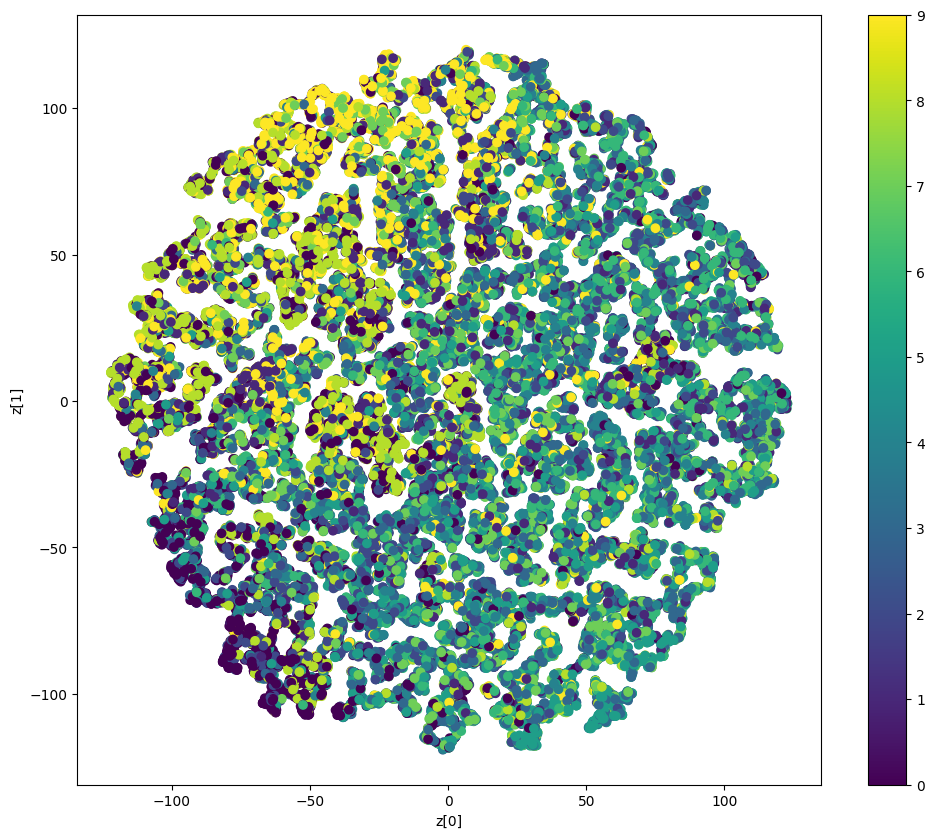

Epoch 1/50
391/391 [==============================] - 127s 325ms/step - loss: 646.0302 - reconstruction_loss: 640.2183 - kl_loss: 5.7559
Epoch 2/50
391/391 [==============================] - 127s 326ms/step - loss: 645.4635 - reconstruction_loss: 640.1521 - kl_loss: 5.7440
Epoch 3/50
391/391 [==============================] - 127s 325ms/step - loss: 645.6567 - reconstruction_loss: 640.1220 - kl_loss: 5.7652
Epoch 4/50
391/391 [==============================] - 127s 326ms/step - loss: 645.5754 - reconstruction_loss: 640.0742 - kl_loss: 5.7715
Epoch 5/50
391/391 [==============================] - 127s 325ms/step - loss: 645.6346 - reconstruction_loss: 640.0897 - kl_loss: 5.7823
Epoch 6/50
391/391 [==============================] - 127s 325ms/step - loss: 645.8496 - reconstruction_loss: 640.0185 - kl_loss: 5.7760
Epoch 7/50
391/391 [==============================] - 127s 325ms/step - loss: 645.9642 - reconstruction_loss: 639.9739 - kl_loss: 5.7785
Epoch 8/50
391/391 [=====================

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Layer, Conv2D, Conv2DTranspose, Dense, Flatten, Reshape
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

class SamplingLayer(Layer):
    def call(self, inputs):
        mean, log_variance = inputs
        bs = tf.shape(mean)[0]
        dim = tf.shape(mean)[1]
        eps = tf.random.normal(shape=(bs, dim))
        return mean + eps * tf.exp(0.5 * log_variance)

latent_dim = 3  # Adjusted to 3D

# Encoder
encoder_input = keras.Input(shape=(32, 32, 3))
x = Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)
x = Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = Flatten()(x)
latent = Dense(128, activation="relu")(x)
mean = Dense(latent_dim, name="mean")(latent)
log_variance = Dense(latent_dim, name="log_variance")(latent)
latent_sample = SamplingLayer()((mean, log_variance))
encoder = keras.Model(encoder_input, [mean, log_variance, latent_sample], name='encoder')
encoder.summary()

# Decoder
decoder_input = keras.Input(shape=(latent_dim,))
x = Dense(8 * 8 * 64, activation="relu")(decoder_input)
x = Reshape((8, 8, 64))(x)
x = Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_output = Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
    
    def train_step(self, data):
        with tf.GradientTape() as tape:
            mean, log_variance, latent_sample = self.encoder(data)
            reconstruction = self.decoder(latent_sample)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_variance - tf.square(mean) - tf.exp(log_variance), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
        
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, _) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(lr=1e-4))
vae.fit(x_train, epochs=30, batch_size=128)

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_label_clusters(vae, data, labels):
    _, _, z = vae.encoder.predict(data)
    tsne = TSNE(n_components=2, random_state=42)
    z_tsne = tsne.fit_transform(z)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

# Plot label clusters in the latent space
plot_label_clusters(vae, x_train, np.squeeze(y_train, axis=1))

vae.fit(x_train, epochs=50, batch_size=128)

In the scatter plot, each point represents an encoded image from the CIFAR-10 dataset, and the color of the point corresponds to its label. The purpose of the scatter plot is to visualize the clusters formed by the encoded representations of different classes. **The distribution in the latent doesn't make intuitive sense - if the VAE has successfully learned meaningful representations, we would expect to see well-separated clusters in the latent space for each class.**

The interpretability of the distribution depends on the complexity and separability of the dataset. CIFAR-10 is a dataset of 50,000 32x32 RGB images belonging to 10 different classes (airplanes, cars, birds, cats etc). In the case of this dataset, one might expect that images of the same class (cars,  birds etc) form distinct clusters in the latent space, but given the complexity and diversity of the images in CIFAR-10, it is challenging to determine a priori what an "intuitive" distribution in the latent space should look like.

In some cases, the clusters might be well-separated, indicating that the VAE has learned to encode images of different classes into distinct regions of the latent space. This would suggest that the VAE has captured some meaningful representations of the data.

It's also possible that the clusters are not well-separated or that there is overlap between different classes. In such cases, the VAE may not have fully captured the underlying structure of the data, or the dataset itself may be inherently challenging to separate.

2. Sample 512 photos from the Celeba dataset and compute the mean face along
with the principal components. Plot the principal components and compare them
with the output of DCGAN. Explain your findings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


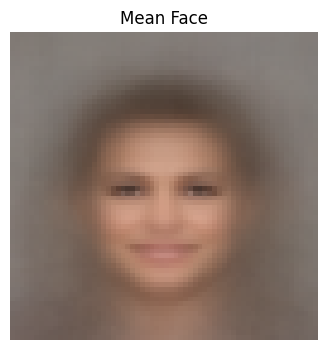

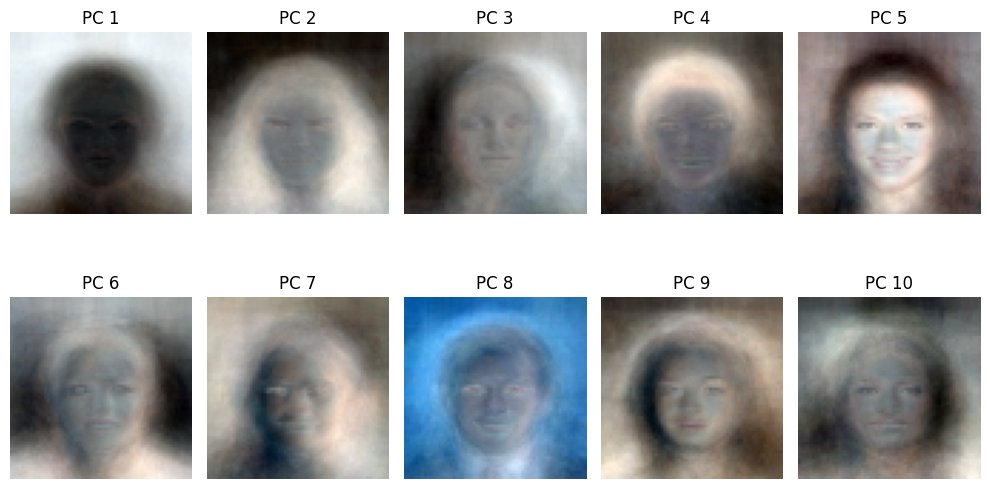

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
import cv2


dataset_dir = "/content/drive/MyDrive/Computer Vision/resurse/w12/celebA"

def load_celeba_images(num_samples):
    image_files = os.listdir(dataset_dir)
    selected_files = np.random.choice(image_files, num_samples, replace=False)
    images = []

    for file in selected_files:
        image = cv2.imread(os.path.join(dataset_dir, file))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (64, 64))
        images.append(image)

    return np.array(images)

# Sample 512 images from the CelebA dataset
num_samples = 512
images = load_celeba_images(num_samples)

# computing the mean face
mean_face = np.mean(images, axis=0)

# preprocess the images for PCA
flattened_images = images.reshape(num_samples, -1)
centered_images = flattened_images - np.mean(flattened_images, axis=0)

pca = PCA(n_components=64)
principal_components = pca.fit_transform(centered_images)

plt.figure(figsize=(4, 4))
plt.imshow(mean_face.astype(np.uint8))
plt.axis('off')
plt.title('Mean Face')
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):  # Plot the first 10 principal components
    plt.subplot(2, 5, i+1)
    pc_image = pca.components_[i].reshape(64, 64, 3)
    
    # normalize the principal component image
    pc_image = (pc_image - pc_image.min()) / (pc_image.max() - pc_image.min())
    
    plt.imshow(pc_image)
    plt.axis('off')
    plt.title(f'PC {i+1}')
plt.tight_layout()
plt.show()


The principal components, computed using PCA, capture the main patterns or variations in the CelebA image dataset. These components represent the directions in the image space along which the images vary the most.

On the other hand, in the DCGAN code, the generator model learns to generate new images that resemble the images in the dataset. The generator takes random noise as input and produces synthetic images as output. **The output of the DCGAN code is a set of generated images.**

The principal components and the generated images are different concepts and represent different aspects of the dataset:

    Principal Components:
        Principal components represent the variations in the image dataset.
        They are calculated based on the pixel values of the original images.
        Each principal component represents a direction in the image space along which the images vary the most.
        The principal components can be visualized as images, and they capture the main patterns or variations in the dataset.

    Generated Images:
        Generated images are synthetic images produced by the generator model.
        They are generated from random noise vectors, not directly from the original images.
        The generator model learns to map the noise vectors to realistic images that resemble the original dataset.
        The generated images aim to capture the overall style and characteristics of the original images, but they are not based on specific variations or patterns extracted from the dataset.

3. Go through [DPED paper](https://arxiv.org/pdf/1704.02470.pdf) and figure out the connection between the loss design
and the objective of the learning procedure. What is the model trained for?

The objective of the learning procedure in the DPED paper is to train a deep residual CNN model that can enhance the quality of low-quality images captured by smartphone cameras to achieve a superior quality similar to images captured by a professional DSLR camera.

The model is trained to minimize a loss function that is designed to capture three independent components of perceptual image quality: color quality, texture quality, and content quality. The loss function is constructed in a way that addresses the challenges of non-linear distortions, local shifts, and variations in optics and sensors between different camera devices.

The loss function consists of multiple terms:

  * Color loss: This term measures the color difference between the enhanced image and the target DSLR image. It uses a Gaussian blur and computes the Euclidean distance between the blurred representations of the images. The color loss ensures that the enhanced image has a similar color distribution to the target image.

  * Texture loss: Instead of using a pre-defined loss function, the paper employs generative adversarial networks (GANs) to learn a suitable metric for measuring texture quality. The discriminator network, trained on grayscale images, distinguishes between fake (improved) and real (target) images. The texture loss is defined as the cross-entropy loss between the discriminator's predictions on the enhanced and target images.

  * Content loss: Inspired by previous works, the content loss is based on the activation maps of the VGG-19 network. It encourages the enhanced image to have similar feature representations as the target image, preserving image semantics.

  * Total variation loss: This term promotes spatial smoothness in the generated images by measuring the total variation of pixel intensities.

The model is trained to minimize a weighted sum of these loss terms, where the weights are chosen based on preliminary experiments on the DPED training data. The overall objective is to train the model to produce enhanced images that exhibit improved color quality, texture quality, and content preservation compared to the original low-quality images.

The model is trained to enhance the perceptual image quality by addressing color, texture, and content aspects using a combination of loss functions specifically designed for each component.